In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline



In [2]:
# ── 1. Load & clean ───────────────────────────────────────────────────────────
df = pd.read_csv("/content/ACWA_DATASET copy.csv")
df = df.drop_duplicates()
df_clean = df.drop(columns=['Temperature_WTP_production', 'Time'], errors='ignore').copy()
df_clean['is_idle'] = (df_clean['Voltage_1_Stack'] == 0).astype(int)
print(f"Shape: {df_clean.shape}")



Shape: (9985, 19)


In [3]:
# ── 2. Scale ──────────────────────────────────────────────────────────────────
numeric_cols = df_clean.select_dtypes(include=['int64','float64']).columns.drop('is_idle')
scaler = RobustScaler()
df_scaled = df_clean.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])



In [4]:
# ── 3. PCA ────────────────────────────────────────────────────────────────────
CLUSTER_FEATS = [c for c in [
    "Current_1_stack", "Voltage_1_Stack", "DC_Power_Consumption_1_Stack",
    "O2_content_in_H2", "H2_content_in_O2", "Lye_Concentration",
    "Lye_Flow_to_1_Stack", "Pressure_O2_Separator", "H2_Separator_Level",
    "O2_Separator_Level", "LDI_H2_&_O2_Separator",
    "H2_Flowrate_Purification_outlet", "DM_water_condctivity",
] if c in df_scaled.columns]

X_pca_input = df_scaled[CLUSTER_FEATS].values
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_pca_input)
print(f"PCA components: {X_pca.shape[1]}  ({pca.explained_variance_ratio_.cumsum()[-1]*100:.1f}% variance)")



PCA components: 3  (96.8% variance)


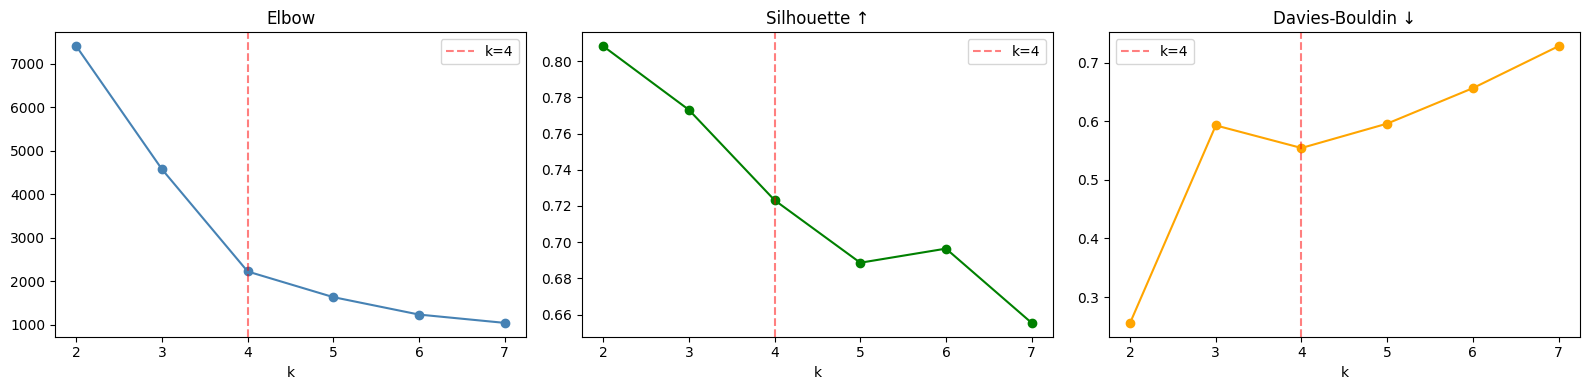

In [5]:
# ── 4. Confirm k=4 is best with plots ─────────────────────────────────────────
inertia, sil, db = [], [], []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_pca)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_pca, lbl))
    db.append(davies_bouldin_score(X_pca, lbl))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(list(K_range), inertia, marker='o', color='steelblue')
axes[0].axvline(4, color='red', linestyle='--', alpha=0.5, label='k=4')
axes[0].set_title("Elbow"); axes[0].set_xlabel("k"); axes[0].legend()

axes[1].plot(list(K_range), sil, marker='o', color='green')
axes[1].axvline(4, color='red', linestyle='--', alpha=0.5, label='k=4')
axes[1].set_title("Silhouette ↑"); axes[1].set_xlabel("k"); axes[1].legend()

axes[2].plot(list(K_range), db, marker='o', color='orange')
axes[2].axvline(4, color='red', linestyle='--', alpha=0.5, label='k=4')
axes[2].set_title("Davies-Bouldin ↓"); axes[2].set_xlabel("k"); axes[2].legend()
plt.tight_layout(); plt.savefig("plot_choose_k.png", dpi=150, bbox_inches='tight'); plt.show()



In [6]:
# ── 5. Fit k=4 ────────────────────────────────────────────────────────────────
BEST_K = 4
km4 = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
raw_labels = km4.fit_predict(X_pca)
df_clean['cluster_raw'] = raw_labels

sil4 = silhouette_score(X_pca, raw_labels)
db4  = davies_bouldin_score(X_pca, raw_labels)
print(f"\nk=4  Silhouette: {sil4:.4f}  |  Davies-Bouldin: {db4:.4f}")




k=4  Silhouette: 0.7232  |  Davies-Bouldin: 0.5546


In [7]:
# ── 6. Map clusters to risk severity using domain knowledge ─────────────────── remov cell
# Use mean of key risk indicators per cluster to rank severity
risk_proxy = df_clean.groupby('cluster_raw')[
    ['O2_content_in_H2', 'H2_content_in_O2', 'Voltage_1_Stack',
     'H2_Separator_Level', 'O2_Separator_Level']
].mean()

print("\nCluster means (used to rank severity):")
print(risk_proxy.round(3))




Cluster means (used to rank severity):
             O2_content_in_H2  H2_content_in_O2  Voltage_1_Stack  \
cluster_raw                                                        
0                       0.000             0.000            0.000   
1                       0.549             1.049          569.607   
2                       0.551             1.051          569.823   
3                       1.630             2.130          569.454   

             H2_Separator_Level  O2_Separator_Level  
cluster_raw                                          
0                         0.000               0.000  
1                        33.087              33.101  
2                        38.982              38.960  
3                        34.517              34.588  


In [8]:
# Rank clusters by combined gas contamination signal (primary risk driver)
risk_proxy['gas_risk_score'] = (
    risk_proxy['O2_content_in_H2'] + risk_proxy['H2_content_in_O2']
)

# Sort clusters from lowest to highest gas risk → assign 0,1,2,3
severity_order = risk_proxy['gas_risk_score'].rank(method='first').astype(int) - 1
cluster_to_severity = severity_order.to_dict()

print("\nCluster → severity mapping:")
for raw, sev in sorted(cluster_to_severity.items()):
    print(f"  Raw cluster {raw} → severity {sev}  "
          f"(gas_risk_score={risk_proxy.loc[raw,'gas_risk_score']:.4f})")

df_clean['risk_level'] = df_clean['cluster_raw'].map(cluster_to_severity)

# Human-readable labels
label_map = {0: 'Normal', 1: 'Degradation warning', 2: 'Gas contamination risk', 3: 'Critical failure'}
df_clean['risk_label'] = df_clean['risk_level'].map(label_map)

print("\nRisk level distribution:")
print(df_clean['risk_label'].value_counts())



Cluster → severity mapping:
  Raw cluster 0 → severity 0  (gas_risk_score=0.0000)
  Raw cluster 1 → severity 1  (gas_risk_score=1.5988)
  Raw cluster 2 → severity 2  (gas_risk_score=1.6027)
  Raw cluster 3 → severity 3  (gas_risk_score=3.7591)

Risk level distribution:
risk_label
Normal                    4284
Degradation warning       3442
Gas contamination risk    1759
Critical failure           500
Name: count, dtype: int64


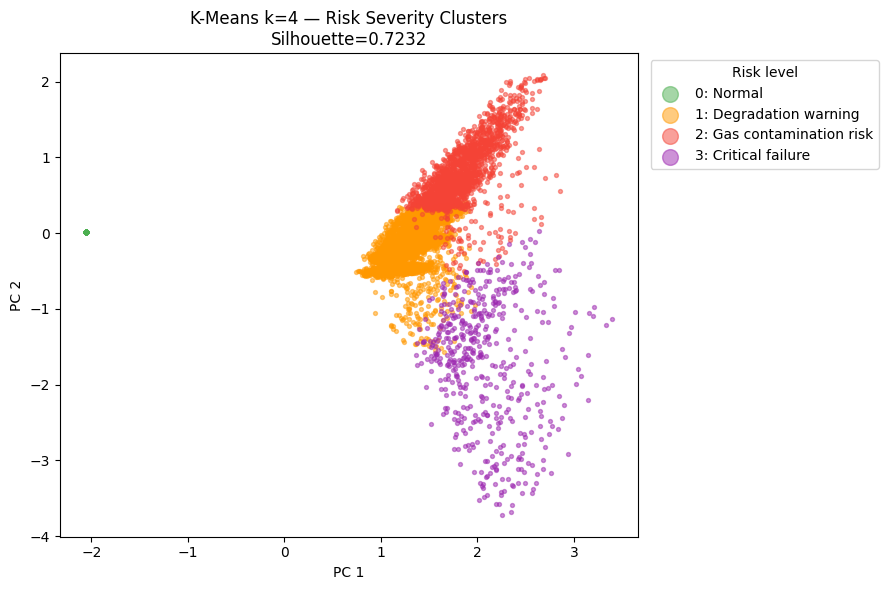

In [9]:

# ── 7. PCA scatter plot coloured by severity ──────────────────────────────────
colors = {0: '#4CAF50', 1: '#FF9800', 2: '#F44336', 3: '#9C27B0'}
fig, ax = plt.subplots(figsize=(9, 6))
for lvl, name in label_map.items():
    mask = df_clean['risk_level'] == lvl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=8, alpha=0.5, color=colors[lvl], label=f"{lvl}: {name}")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
ax.set_title(f"K-Means k=4 — Risk Severity Clusters\nSilhouette={sil4:.4f}")
ax.legend(markerscale=4, title="Risk level", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout(); plt.savefig("plot_pca_k4.png", dpi=150, bbox_inches='tight'); plt.show()



In [10]:
# ── 8. Risk breakdown per cluster ─────────────────────────────────────────────
print("\nFeature means per risk level:")
print(df_clean.groupby('risk_label')[
    ['Voltage_1_Stack', 'O2_content_in_H2', 'H2_content_in_O2',
     'Lye_Concentration', 'Pressure_O2_Separator']
].mean().round(3).T)




Feature means per risk level:
risk_label             Critical failure  Degradation warning  \
Voltage_1_Stack                 569.454              569.607   
O2_content_in_H2                  1.630                0.549   
H2_content_in_O2                  2.130                1.049   
Lye_Concentration                31.030               31.129   
Pressure_O2_Separator            15.492               15.494   

risk_label             Gas contamination risk  Normal  
Voltage_1_Stack                       569.823     0.0  
O2_content_in_H2                        0.551     0.0  
H2_content_in_O2                        1.051     0.0  
Lye_Concentration                      30.737     0.0  
Pressure_O2_Separator                  15.502     0.0  


In [11]:
# ── 9. Model features — NO leakage columns ───────────────────────────────────
MODEL_FEATURES = [c for c in [
    "Room_temperature", "Current_1_stack", "Voltage_1_Stack",
    "DC_Power_Consumption_1_Stack", "H2_side_outlet_temp_1_stack",
    "O2_side_outlet_temp_1_stack", "Lye_Supply_to_Electrolyzer_Temp",
    "Lye_Concentration", "Lye_Flow_to_1_Stack", "H2_Separator_Level",
    "O2_Separator_Level", "LDI_H2_&_O2_Separator", "Pressure_O2_Separator",
    "H2_Flowrate_Purification_outlet", "DM_water_condctivity",
    "DM_water_flow_from_B.L.", "is_idle",
    # O2_content_in_H2 and H2_content_in_O2 EXCLUDED — used to define labels
    # cluster_raw, risk_level, risk_label EXCLUDED — these ARE the target
] if c in df_clean.columns]

print("\nFeatures used:", MODEL_FEATURES)
print("Leakage check:", [c for c in [
    'O2_content_in_H2','H2_content_in_O2','cluster_raw','risk_level','risk_label'
] if c in MODEL_FEATURES])  # must print []

X_model = df_clean[MODEL_FEATURES].values
y_model = df_clean['risk_level'].values   # 4 classes: 0,1,2,3

print("\nClass distribution:")
for lvl, name in label_map.items():
    count = (y_model == lvl).sum()
    pct = count / len(y_model) * 100
    print(f"  Class {lvl} ({name}): {count} rows ({pct:.1f}%)")




Features used: ['Room_temperature', 'Current_1_stack', 'Voltage_1_Stack', 'DC_Power_Consumption_1_Stack', 'H2_side_outlet_temp_1_stack', 'O2_side_outlet_temp_1_stack', 'Lye_Supply_to_Electrolyzer_Temp', 'Lye_Concentration', 'Lye_Flow_to_1_Stack', 'H2_Separator_Level', 'O2_Separator_Level', 'LDI_H2_&_O2_Separator', 'Pressure_O2_Separator', 'H2_Flowrate_Purification_outlet', 'DM_water_condctivity', 'DM_water_flow_from_B.L.', 'is_idle']
Leakage check: []

Class distribution:
  Class 0 (Normal): 4284 rows (42.9%)
  Class 1 (Degradation warning): 3442 rows (34.5%)
  Class 2 (Gas contamination risk): 1759 rows (17.6%)
  Class 3 (Critical failure): 500 rows (5.0%)


In [12]:
# ── 10. Split → SMOTE inside pipeline → train ─────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42, stratify=y_model
)

# SMOTE for multi-class — oversamples all minority classes
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf',   RandomForestClassifier(
                  n_estimators=200,
                  class_weight='balanced',
                  random_state=42,
                  n_jobs=-1))
])

print("\nBefore SMOTE (train):", dict(zip(*np.unique(y_train, return_counts=True))))
pipeline.fit(X_train, y_train)

# Check SMOTE result
X_sm, y_sm = pipeline.named_steps['smote'].fit_resample(X_train, y_train)
print("After  SMOTE (train):", dict(zip(*np.unique(y_sm, return_counts=True))))




Before SMOTE (train): {np.int64(0): np.int64(3427), np.int64(1): np.int64(2754), np.int64(2): np.int64(1407), np.int64(3): np.int64(400)}
After  SMOTE (train): {np.int64(0): np.int64(3427), np.int64(1): np.int64(3427), np.int64(2): np.int64(3427), np.int64(3): np.int64(3427)}


In [13]:
# ── 11. Evaluate ──────────────────────────────────────────────────────────────
y_pred = pipeline.predict(X_test)

print("\n── Test set evaluation ────────────────────────────────────────")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=[label_map[i] for i in sorted(label_map)]))




── Test set evaluation ────────────────────────────────────────
Accuracy: 0.9965

Classification Report:
                        precision    recall  f1-score   support

                Normal       1.00      1.00      1.00       857
   Degradation warning       1.00      1.00      1.00       688
Gas contamination risk       1.00      0.99      0.99       352
      Critical failure       0.95      0.99      0.97       100

              accuracy                           1.00      1997
             macro avg       0.99      0.99      0.99      1997
          weighted avg       1.00      1.00      1.00      1997



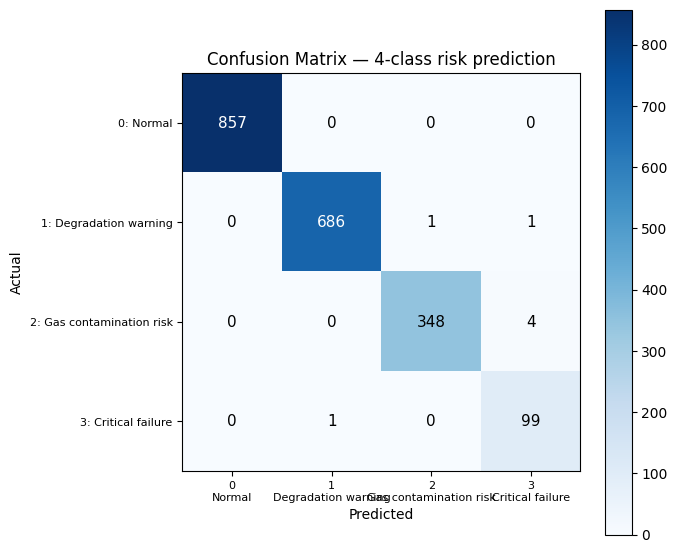

In [14]:
# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels([f"{i}\n{label_map[i]}" for i in range(4)], fontsize=8)
ax.set_yticklabels([f"{i}: {label_map[i]}" for i in range(4)], fontsize=8)
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=11)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — 4-class risk prediction")
plt.colorbar(im); plt.tight_layout()
plt.savefig("plot_confusion_matrix.png", dpi=150, bbox_inches='tight'); plt.show()



In [15]:
# ── 12. Cross-validation ──────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    pipeline, X_train, y_train, cv=cv,
    scoring=['accuracy', 'f1_weighted', 'recall_weighted'],
    return_train_score=False
)
print("\n── 5-fold cross-validation ────────────────────────────────────")
for m in ['accuracy', 'f1_weighted', 'recall_weighted']:
    s = cv_results[f'test_{m}']
    print(f"  {m:20s}: {s.mean():.4f} ± {s.std():.4f}")




── 5-fold cross-validation ────────────────────────────────────
  accuracy            : 0.9959 ± 0.0021
  f1_weighted         : 0.9959 ± 0.0021
  recall_weighted     : 0.9959 ± 0.0021


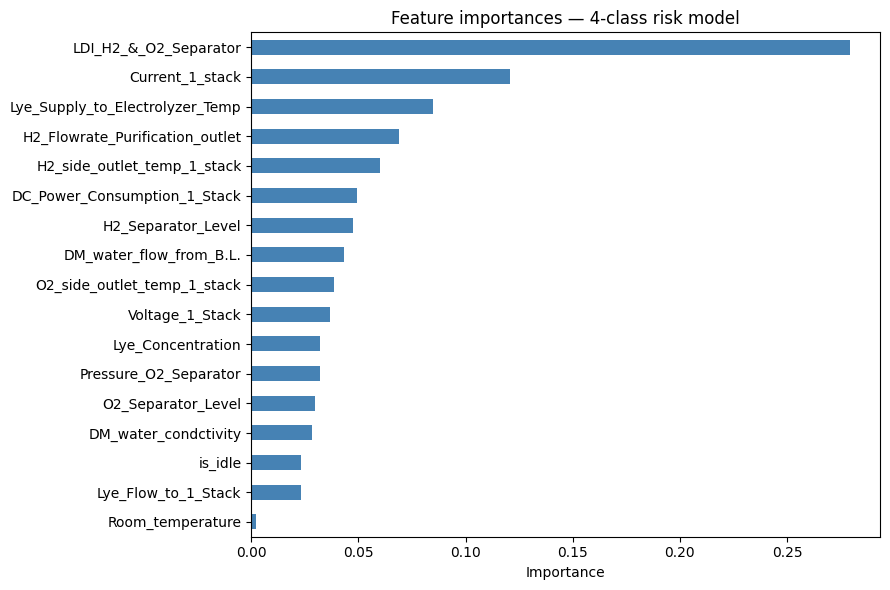

In [16]:
# ── 13. Feature importance ────────────────────────────────────────────────────
importances = pd.Series(
    pipeline.named_steps['clf'].feature_importances_,
    index=MODEL_FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Feature importances — 4-class risk model")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("plot_feature_importance.png", dpi=150, bbox_inches='tight'); plt.show()



In [17]:
# ── 14. Save ──────────────────────────────────────────────────────────────────
df_clean.to_csv("ACWA_k4_output.csv", index=False)
print("\nSaved → ACWA_k4_output.csv")
print("Columns:", list(df_clean.columns))


Saved → ACWA_k4_output.csv
Columns: ['Room_temperature', 'Current_1_stack', 'Voltage_1_Stack', 'DC_Power_Consumption_1_Stack', 'H2_side_outlet_temp_1_stack', 'O2_side_outlet_temp_1_stack', 'Lye_Supply_to_Electrolyzer_Temp', 'Lye_Concentration', 'Lye_Flow_to_1_Stack', 'H2_Separator_Level', 'O2_Separator_Level', 'LDI_H2_&_O2_Separator', 'O2_content_in_H2', 'H2_content_in_O2', 'Pressure_O2_Separator', 'H2_Flowrate_Purification_outlet', 'DM_water_condctivity', 'DM_water_flow_from_B.L.', 'is_idle', 'cluster_raw', 'risk_level', 'risk_label']


In [19]:
df = pd.read_csv("/content/ACWA_k4_output.csv")
df

,Room_temperature,Current_1_stack,Voltage_1_Stack,DC_Power_Consumption_1_Stack,H2_side_outlet_temp_1_stack,O2_side_outlet_temp_1_stack,Lye_Supply_to_Electrolyzer_Temp,Lye_Concentration,Lye_Flow_to_1_Stack,H2_Separator_Level,...,O2_content_in_H2,H2_content_in_O2,Pressure_O2_Separator,H2_Flowrate_Purification_outlet,DM_water_condctivity,DM_water_flow_from_B.L.,is_idle,cluster_raw,risk_level,risk_label
0,25.75,0.0,0,0.0,25.75,25.75,25.75,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,Normal
1,24.75,0.0,0,0.0,25.25,25.25,25.25,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,Normal
2,24.75,0.0,0,0.0,24.75,24.75,24.75,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,Normal
3,24.75,0.0,0,0.0,24.75,24.75,24.75,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,Normal
4,24.50,0.0,0,0.0,24.50,24.50,24.50,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9980,24.75,0.0,0,0.0,25.25,25.25,25.25,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,Normal
9981,24.75,0.0,0,0.0,24.75,24.75,24.75,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,Normal
9982,25.25,0.0,0,0.0,25.25,25.25,25.25,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,Normal
9983,24.25,0.0,0,0.0,24.75,24.75,24.75,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,Normal


In [20]:
df["risk_label"].value_counts()

,count
risk_label,
Normal,4284
Degradation warning,3442
Gas contamination risk,1759
Critical failure,500
